Example 1: Simple 3x3 Symmetric Positive-Definite System

Matrix A:
[[4. 1. 0.]
 [1. 3. 1.]
 [0. 1. 2.]]

Right-hand side b:
[1. 2. 3.]
Converged in 3 iterations

Solution using CG:
[0.22222222 0.11111111 1.44444444]

Solution using direct solver (for verification):
[0.22222222 0.11111111 1.44444444]

Error: 2.69e-16

Example 2: 2D Poisson Equation (50x50 grid)
This mimics the pressure equation in incompressible flow

Solving 2500x2500 system...
Converged in 175 iterations
Final residual: 9.39e-09

Plot saved as 'cg_results.png'


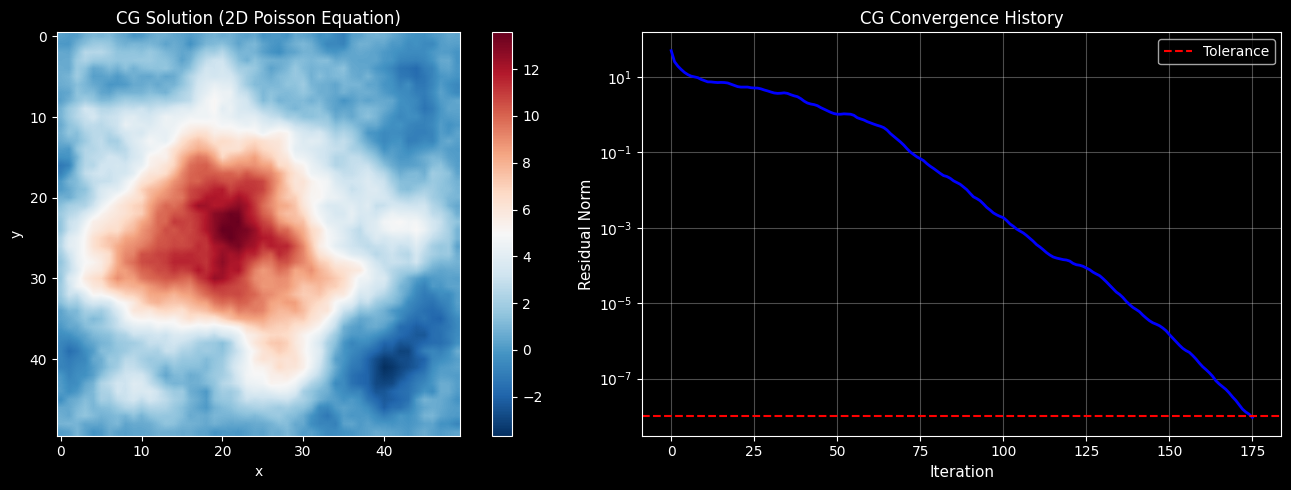


Key Observations:
• System size: 2500 unknowns
• Iterations to convergence: 175
• Theoretical max iterations: 2500
• Speedup: converged in 7.0% of max iterations
• This demonstrates why CG is so efficient for large sparse systems!


In [1]:
import numpy as np
import matplotlib.pyplot as plt

def conjugate_gradient(A, b, x0=None, tol=1e-10, max_iter=None):
    """
    Solve Ax = b using Conjugate Gradient method
    
    Parameters:
    A: symmetric positive-definite matrix (n x n)
    b: right-hand side vector (n,)
    x0: initial guess (n,) - if None, uses zero vector
    tol: convergence tolerance
    max_iter: maximum iterations - if None, uses n
    
    Returns:
    x: solution vector
    residuals: list of residual norms at each iteration
    """
    n = len(b)
    if x0 is None:
        x = np.zeros(n)
    else:
        x = x0.copy()
    
    if max_iter is None:
        max_iter = n
    
    # Initial residual and search direction
    r = b - A @ x
    p = r.copy()
    
    residuals = [np.linalg.norm(r)]
    
    for k in range(max_iter):
        # Compute step size alpha
        Ap = A @ p
        r_dot_r = r @ r
        alpha = r_dot_r / (p @ Ap)
        
        # Update solution and residual
        x = x + alpha * p
        r_new = r - alpha * Ap
        
        # Check convergence
        residual_norm = np.linalg.norm(r_new)
        residuals.append(residual_norm)
        
        if residual_norm < tol:
            print(f"Converged in {k+1} iterations")
            break
        
        # Compute beta and update search direction
        beta = (r_new @ r_new) / r_dot_r
        p = r_new + beta * p
        r = r_new
    
    return x, residuals

# Example 1: Simple 3x3 system
print("="*60)
print("Example 1: Simple 3x3 Symmetric Positive-Definite System")
print("="*60)

# Create a symmetric positive-definite matrix
A1 = np.array([[4.0, 1.0, 0.0],
               [1.0, 3.0, 1.0],
               [0.0, 1.0, 2.0]])

b1 = np.array([1.0, 2.0, 3.0])

print("\nMatrix A:")
print(A1)
print("\nRight-hand side b:")
print(b1)

# Solve using CG
x_cg, residuals1 = conjugate_gradient(A1, b1)

print("\nSolution using CG:")
print(x_cg)

# Verify with direct solver
x_direct = np.linalg.solve(A1, b1)
print("\nSolution using direct solver (for verification):")
print(x_direct)

print(f"\nError: {np.linalg.norm(x_cg - x_direct):.2e}")

# Example 2: Larger system - 2D Poisson equation (like pressure in Navier-Stokes)
print("\n" + "="*60)
print("Example 2: 2D Poisson Equation (50x50 grid)")
print("="*60)
print("This mimics the pressure equation in incompressible flow")

def create_2d_poisson_matrix(n):
    """
    Create matrix for 2D Poisson equation using finite differences
    -∇²u = f on a square domain
    This is similar to the pressure Poisson equation in Navier-Stokes
    """
    N = n * n
    A = np.zeros((N, N))
    
    for i in range(n):
        for j in range(n):
            idx = i * n + j
            
            # Diagonal element
            A[idx, idx] = 4.0
            
            # Off-diagonal elements (neighbors)
            if i > 0:  # left neighbor
                A[idx, idx - n] = -1.0
            if i < n - 1:  # right neighbor
                A[idx, idx + n] = -1.0
            if j > 0:  # bottom neighbor
                A[idx, idx - 1] = -1.0
            if j < n - 1:  # top neighbor
                A[idx, idx + 1] = -1.0
    
    return A

# Grid size
n = 50
N = n * n

# Create Poisson matrix
A2 = create_2d_poisson_matrix(n)

# Create right-hand side (simulating a source term)
b2 = np.random.randn(N)

print(f"\nSolving {N}x{N} system...")

# Solve using CG
x_cg2, residuals2 = conjugate_gradient(A2, b2, tol=1e-8)

print(f"Final residual: {residuals2[-1]:.2e}")

# Reshape solution for visualization
x_grid = x_cg2.reshape(n, n)

# Create visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Solution
im1 = axes[0].imshow(x_grid, cmap='RdBu_r', interpolation='bilinear')
axes[0].set_title('CG Solution (2D Poisson Equation)', fontsize=12)
axes[0].set_xlabel('x')
axes[0].set_ylabel('y')
plt.colorbar(im1, ax=axes[0])

# Plot 2: Convergence history
axes[1].semilogy(residuals2, 'b-', linewidth=2)
axes[1].grid(True, alpha=0.3)
axes[1].set_xlabel('Iteration', fontsize=11)
axes[1].set_ylabel('Residual Norm', fontsize=11)
axes[1].set_title('CG Convergence History', fontsize=12)
axes[1].axhline(y=1e-8, color='r', linestyle='--', label='Tolerance')
axes[1].legend()

plt.tight_layout()
plt.savefig('cg_results.png', dpi=150, bbox_inches='tight')
print("\nPlot saved as 'cg_results.png'")
plt.show()

print("\n" + "="*60)
print("Key Observations:")
print("="*60)
print(f"• System size: {N} unknowns")
print(f"• Iterations to convergence: {len(residuals2)-1}")
print(f"• Theoretical max iterations: {N}")
print(f"• Speedup: converged in {100*(len(residuals2)-1)/N:.1f}% of max iterations")
print("• This demonstrates why CG is so efficient for large sparse systems!")